## Imports

In [1]:
!pip install git+https://github.com/mimoralea/gym-bandits#egg=gym-bandits
!pip install git+https://github.com/mimoralea/gym-walk#egg=gym-walk

  Cloning https://github.com/mimoralea/gym-bandits to c:\users\lenovo\appdata\local\temp\pip-install-pex461mm\gym-bandits_30d30cac87dc471f8f51d5bbdd1755df
  Resolved https://github.com/mimoralea/gym-bandits to commit f4b45d39e59eee3f6377ceb42466749af2cd77bd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached gym-0.26.2.tar.gz (721 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gym-bandits: filename=gym_bandits-0.1-py3-none-any.whl size=5345 sha256=8b3f241326e7c0eddc82b67bb5c52ebb940eb69b762843adcca6a90b8b1a7a63
  Stored in directory: C:\Users\Lenovo\AppData\Local\Temp\pip-ephem-wheel-cache-ojtok4bw\wheels\e1\4a\04\520c21

  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-bandits 'C:\Users\Lenovo\AppData\Local\Temp\pip-install-pex461mm\gym-bandits_30d30cac87dc471f8f51d5bbdd1755df'
  DEPRECATION: Building 'gym-bandits' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'gym-bandits'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Cloning https://github.com/mimoralea/gym-walk to c:\users\lenovo\appdata\local\temp\pip-install-xg96t7rq\gym-walk_81794b6783b84835b5bb69ca20a4da50
  Resolved https://github.com/mimoralea/gym-walk to commit b915b94cf2ad16f8833a1ad92ea94e88159279f5
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for gym-walk: filename=gym_walk-0.0.2-py3-none-any.whl size=5492 sha256=958e9de1a577a093fd093c23b62bbf78ceb376f07a8ca07b40d404c41ed26a33
  Stored in directory: C:\Users\Lenovo\AppData\Local\Temp\pip-ephem-wheel-cache-g0toji1t\wheels\60\02\77\2dd9f31df8d13bc7c014725f4002e29d0fc3ced5e8ac08e1cf
Successfully built gym-walk


  Running command git clone --filter=blob:none --quiet https://github.com/mimoralea/gym-walk 'C:\Users\Lenovo\AppData\Local\Temp\pip-install-xg96t7rq\gym-walk_81794b6783b84835b5bb69ca20a4da50'
  DEPRECATION: Building 'gym-walk' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'gym-walk'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [104]:
import numpy as np
import gymnasium as gym

import warnings ; warnings.filterwarnings('ignore')

from pprint import pprint
# from tqdm import tqdm_notebook as tqdm
from tqdm.notebook import tqdm

from itertools import cycle
import matplotlib.pyplot as plt
import random

np.set_printoptions(suppress=True)
random.seed(123); np.random.seed(123)
SEEDS = (12, 34, 56, 78, 90)


import warnings ; warnings.filterwarnings('ignore')

import numpy as np
from scipy.special import softmax as softmax_fn
from pprint import pprint
from tqdm import tqdm_notebook as tqdm

from itertools import cycle

import sys
import gym_bandits
import gym

## Env

In [42]:
env = gym.make("BanditTenArmedGaussian-v0")
env.reset()

0

  0%|          | 0/100000 [00:00<?, ?it/s]

(array([    1.,     1.,    11.,    80.,   288.,  1016.,  2752.,  6060.,
        10853., 15520., 17798., 17346., 13128.,  8417.,  4182.,  1759.,
          594.,   151.,    34.,     9.]),
 array([-4.58520485, -4.12646944, -3.66773402, -3.20899861, -2.75026319,
        -2.29152778, -1.83279236, -1.37405695, -0.91532153, -0.45658612,
         0.00214929,  0.46088471,  0.91962012,  1.37835554,  1.83709095,
         2.29582637,  2.75456178,  3.2132972 ,  3.67203261,  4.13076802,
         4.58950344]),
 <BarContainer object of 20 artists>)

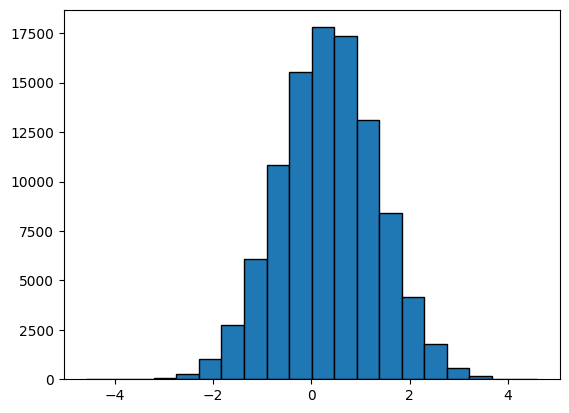

In [45]:
Q = np.zeros((env.action_space.n))
action = np.argmax(Q)

_, reward, _ , _ = env.step(action)
rewards=[]
for i in tqdm( range (100000)):
  _, reward, _ , _ = env.step(action)
  rewards.append(reward)

## distribution of rewards for many iterations

import matplotlib.pyplot as plt

plt.hist(rewards, edgecolor='black', bins=20)

In [ ]:
print(env.env.r_dist)
print(env.env.p_dist)

In [46]:
b10_Vs = []
for seed in SEEDS:
    env_name = 'BanditTenArmedGaussian-v0'
    env = gym.make(env_name, seed=seed) ; env.reset()
    r_dist = np.array(env.env.r_dist)[:,0]
    b10_Q = np.array(env.env.p_dist * r_dist)

    print('10-Armed Bandit environment with seed', seed)
    ## reward always pays out --> so prob of getting reward is always 1
    print('Probability of reward:', env.env.p_dist)
    ## reward values will change as per the seed
    print('Reward:', r_dist)

    print('Q(.):', b10_Q)

    b10_Vs.append(np.max(b10_Q))

    print('V*:', b10_Vs[-1])

    print()
print('Mean V* across all seeds:', np.mean(b10_Vs))

10-Armed Bandit environment with seed 12
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
Q(.): [-0.00682678  1.04614329  0.74158842  0.72395654  1.61877622 -1.20555814
 -0.62695547 -1.32066321 -0.10775251  0.99876366]
V*: 1.6187762233340763

10-Armed Bandit environment with seed 34
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
Q(.): [-0.03992466 -1.25773672  2.57402319  0.48179798  0.64354662 -0.20792668
  0.05828708  0.33674264  0.19510709 -0.60931449]
V*: 2.574023189963745

10-Armed Bandit environment with seed 56
Probability of reward: [1 1 1 1 1 1 1 1 1 1]
Reward: [-0.84994072  0.32194085  1.78904286  0.8793392   0.37159282  1.48769378
  0.72866553  2.08124873 -1.33726808  0.12535155]
Q(.): [-0.84994072  0.32194085  1.78904286  

# Strategies

## Pure exploitation


In [ ]:
def bandit_pure_exploit(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name = 'pure_exploitation'
  for e in tqdm(range(n_episodes), desc = "Episodes for : "+name, leave = False):
    ## always select the action with highest current Q-value-- this is where the exploitation is happening
    action = np.argmax(Q)
    ## taking the action we are getting some reward
    _, reward, _ , _ = env.step(action)
    ## count
    N[action] +=1
    ## updating the Q table
    Q[action] = Q[action] +(reward - Q[action])/N[action]

    ## storing data in the Final tables
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions

In [ ]:
name, returns, Qe, actions= bandit_pure_exploit(env)

In [ ]:
print("Qe shape",Qe.shape)
print()
print(Qe[55])
print(Qe[550])
print(Qe[54,0])

In [ ]:
plt.hist(returns)

In [ ]:
plt.hist(Qe[:,0], bins=300)

## Pure Exoploration

In [ ]:
def pure_explore(env, n_episodes=5000):
  Q =np.zeros((env.action_space.n))
  N =np.zeros((env.action_space.n))

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name ='pure exploration'
  for e in tqdm(range(n_episodes), desc = 'Episodes for: '+name, leave=False):
    action = np.random.randint(len(Q))
    _, reward, _ , _ = env.step(action)
    ## count
    N[action] +=1
    ## updating the Q table
    Q[action] = Q[action] +(reward - Q[action])/N[action]

    ## storing data in the Final tables
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions


In [ ]:
name, returns, Qe, actions = pure_explore(env)
print("Qe shape",Qe.shape)
print()
print("55 ",Qe[55])
print("550 ",Qe[550])
print("54 ",Qe[54])
print("=========================")
plt.hist(returns)

In [ ]:
print("Qe shape",Qe.shape)
print()
print("55 ",Qe[55])
print("550 ",Qe[550])
print("54 ",Qe[54])
print("=========================")
plt.hist(returns)

## Optimistic Initialization

In [58]:
## decoding the strategy
optimistic_estimate =1.0
initial_count =100
n_episodes=5000

Q =np.full((env.action_space.n), optimistic_estimate, dtype=float)
print("Q: ", Q, "Size : ",Q.shape)
N =np.full((env.action_space.n), initial_count, dtype=float)
print("N: ", N, "Size : ",N.shape)
## storing estimates for each episodes
Qe = np.empty((n_episodes, env.action_space.n))
returns = np.empty(n_episodes)
actions = np.empty(n_episodes, dtype=int)



Q:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] Size :  (10,)
N:  [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.] Size :  (10,)


In [59]:
name ='optimistic'
for e in tqdm(range(n_episodes), desc = 'Episodes for: '+name, leave=False):
  action = np.argmax(Q)
  print("action taken:", action)
  _, reward, _ , _ = env.step(action)
  ## count
  N[action] +=1
  # print(N[action])
  ## updating the Q table
  Q[action] = Q[action] +(reward - Q[action])/N[action]
  print("Q values update check :" ,Q)
  ## storing data in the Final tables
  Qe[e] = Q
  returns[e] =reward
  actions[e] = action

print("==================================")
print( name, returns, Qe, actions )

Episodes for: optimistic:   0%|          | 0/5000 [00:00<?, ?it/s]

action taken: 0
Q values update check : [1.00107031 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]
action taken: 0
Q values update check : [0.99903129 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]
action taken: 1
Q values update check : [0.99903129 0.98365913 1.         1.         1.         1.
 1.         1.         1.         1.        ]
action taken: 2
Q values update check : [0.99903129 0.98365913 0.99230872 1.         1.         1.
 1.         1.         1.         1.        ]
action taken: 3
Q values update check : [0.99903129 0.98365913 0.99230872 0.99093378 1.         1.
 1.         1.         1.         1.        ]
action taken: 4
Q values update check : [0.99903129 0.98365913 0.99230872 0.99093378 0.97311495 1.
 1.         1.         1.         1.        ]
action taken: 5
Q values update check : [0.99903129 0.98365913 0.99230872 0.99093378 0.97311495 0.98184416
 1.         1.         

if we increase the Q value then the algo will push for more exploration

In [ ]:
def optimistic(env, optimistic_estimate =1.0, initial_count =100, n_episodes=5000):
  Q =np.full((env.action_space.n), optimistic_estimate, dtype=float)
  N =np.full((env.action_space.n), initial_count, dtype=float)

  ## storing estimates for each episodes
  Qe = np.empty((n_episodes, env.action_space.n))
  returns = np.empty(n_episodes)
  actions = np.empty(n_episodes, dtype=int)

  name ='optimistic'
  for e in tqdm(range(n_episodes), desc = 'Episodes for: '+name, leave=False):
    action = np.argmax(Q)
    _, reward, _ , _ = env.step(action)
    ## count
    N[action] +=1
    ## updating the Q table
    Q[action] = Q[action] +(reward - Q[action])/N[action]

    ## storing data in the Final tables
    Qe[e] = Q
    returns[e] =reward
    actions[e] = action

  return name, returns, Qe, actions


Episodes for: optimistic:   0%|          | 0/50000 [00:00<?, ?it/s]

Qe shape (50000, 10)

55  [1.3322234 1.        1.        1.        1.        1.        1.
 1.        1.        1.       ]
550  [1.73142752 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]
54  [1.33562551 1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]


(array([    8.,   126.,  1267.,  5770., 13656., 15960.,  9768.,  2958.,
          453.,    34.]),
 array([-2.63375588, -1.78990891, -0.94606193, -0.10221496,  0.74163202,
         1.58547899,  2.42932597,  3.27317294,  4.11701992,  4.96086689,
         5.80471387]),
 <BarContainer object of 10 artists>)

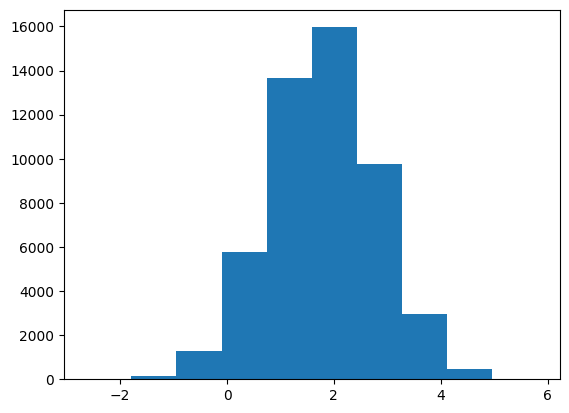

In [64]:
name, returns, Qe, actions = optimistic(env,n_episodes=50000)
print("Qe shape",Qe.shape)
print()
print("55 ",Qe[55])
print("550 ",Qe[550])
print("54 ",Qe[54])
print("=========================")
plt.hist(returns)

## softmax strategy


In [58]:
env, env.reset()
init_temp=float('inf')
min_temp=0.0
decay_ratio=0.04
n_episodes=500


Q =np.zeros((env.action_space.n), dtype=float)
N =np.zeros((env.action_space.n), dtype= int)

## storing estimates for each episodes
Qe = np.empty((n_episodes, env.action_space.n), dtype =float)
returns = np.empty(n_episodes, dtype=float)
actions = np.empty(n_episodes, dtype=int)

# print("Qe: ", Qe)
# print("returns: ", returns)
# print("actions : ", actions)
name = 'Lin SoftMax {}, {}, {}'.format(init_temp, min_temp, decay_ratio)


# can't really use infinity
init_temp = np.minimum(init_temp, sys.float_info.max)
print("initial temp ", init_temp)
# can't really use zero
min_temp = max(min_temp, np.nextafter(np.float32(0), np.float32(1)))
print("minimum temp: ",min_temp)


initial temp  1.7976931348623157e+308
minimum temp:  1e-45


In [86]:
probability = [0., 0. ,0. ,0. ,0. ,0., 0., 0. ,0. ,1.]
action = np.random.choice(np.arange(len(probability)),
                              size=1,
                              p=probability)[0]
# print(action)
p = np.random.choice(10, size=2, p=probability)
p[0]

np.int64(9)

In [59]:
for e in tqdm(range(n_episodes), desc='Episodes for: ' + name, leave=False):

    decay_episodes = n_episodes * decay_ratio
    temp = 1 - e / decay_episodes
    temp *= init_temp - min_temp
    temp += min_temp
    temp = np.clip(temp, min_temp, init_temp)
    print("Q value before the deciding prob : ", Q)

    scaled_Q = Q / temp
    norm_Q = scaled_Q - np.max(scaled_Q)
    exp_Q = np.exp(norm_Q)
    probs = exp_Q / np.sum(exp_Q)
    assert np.isclose(probs.sum(), 1.0)
    ## prob will be equal for long time because of high Temp value
    print("prob: ", probs)

    ## action is Random here.. exploration
    action = np.random.choice(np.arange(len(probs)),
                              size=1,
                              p=probs)[0]
    print("action:",action)

    _, reward, _, _ = env.step(action)
    N[action] += 1
    Q[action] = Q[action] + (reward - Q[action])/N[action]
    print("Q values after the action : ", Q)

    print("%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%========================")
    Qe[e] = Q
    returns[e] = reward
    actions[e] = action



print( name, returns, Qe, actions)

Episodes for: Lin SoftMax inf, 0.0, 0.04:   0%|          | 0/500 [00:00<?, ?it/s]

Q value before the deciding prob :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
prob:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
action: 3
Q values after the action :  [ 0.          0.          0.         -1.51053072  0.          0.
  0.          0.          0.          0.        ]
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%========================
Q value before the deciding prob :  [ 0.          0.          0.         -1.51053072  0.          0.
  0.          0.          0.          0.        ]
prob:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
action: 0
Q values after the action :  [ 0.64357025  0.          0.         -1.51053072  0.          0.
  0.          0.          0.          0.        ]
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%========================
Q value before the deciding prob :  [ 0.64357025  0.          0.         -1.51053072  0.          0.
  0.          0.          0.          0.        ]
prob:  [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
action: 8
Q values after the acti

In [87]:
## using as function
## print lines are removed
def softmax(env,
            init_temp=float('inf'),
            min_temp=0.0,
            decay_ratio=0.04,
            n_episodes=1000):
    Q = np.zeros((env.action_space.n), dtype=np.float64)
    N = np.zeros((env.action_space.n), dtype=np.int)

    Qe = np.empty((n_episodes, env.action_space.n), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=np.int)
    name = 'Lin SoftMax {}, {}, {}'.format(init_temp,
                                           min_temp,
                                           decay_ratio)
    # can't really use infinity
    init_temp = min(init_temp,
                    sys.float_info.max)
    # can't really use zero
    min_temp = max(min_temp,
                   np.nextafter(np.float32(0),
                                np.float32(1)))
    for e in tqdm(range(n_episodes),
                  desc='Episodes for: ' + name,
                  leave=False):
        decay_episodes = n_episodes * decay_ratio
        temp = 1 - e / decay_episodes
        temp *= init_temp - min_temp
        temp += min_temp
        temp = np.clip(temp, min_temp, init_temp)

        scaled_Q = Q / temp
        norm_Q = scaled_Q - np.max(scaled_Q)
        exp_Q = np.exp(norm_Q)
        probs = exp_Q / np.sum(exp_Q)
        assert np.isclose(probs.sum(), 1.0)

        action = np.random.choice(np.arange(len(probs)),
                                  size=1,
                                  p=probs)[0]

        _, reward, _, _ = env.step(action)
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]

        Qe[e] = Q
        returns[e] = reward
        actions[e] = action
    return name, returns, Qe, actions

## Upper Confident Bound

In [122]:
env.reset()
c=2
n_episodes=5000

Q = np.zeros((env.action_space.n), dtype=np.float64)
N = np.zeros((env.action_space.n), dtype=int)
Us=[]
Qe = np.empty((n_episodes, env.action_space.n), dtype=np.float64)
returns = np.empty(n_episodes, dtype=np.float64)
actions = np.empty(n_episodes, dtype=int)
name = 'UCB {}'.format(c)

In [96]:
len(Q)

10

In [123]:
for e in tqdm(range(n_episodes),
              desc='Episodes for: ' + name,
              leave=False):

    action = e
    print("action/step: ", action)

    ## after the length of Q this condition will start working -- here it will start after 9
    if e >= len(Q):
        U = c * np.sqrt(np.log(e)/N)
        action = np.argmax(Q + U)
        Us.append(U)
    print("action after checking condition:", action)

    _, reward, _, _ = env.step(action)
    print("reward:", reward)
    N[action] += 1
    Q[action] = Q[action] + (reward - Q[action])/N[action]
    print("Q",Q)
    print("=================================================")
    Qe[e] = Q
    returns[e] = reward
    actions[e] = action


Episodes for: UCB 2:   0%|          | 0/5000 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
 -0.69750287  0.47244872  0.39466958  0.32726662]
action/step:  4167
action after checking condition: 4
reward: 1.7667987612984082
Q [-0.04304433  0.85300468  0.16474789 -1.16540148  0.91496814  0.60165084
 -0.69750287  0.47244872  0.39466958  0.32726662]
action/step:  4168
action after checking condition: 4
reward: 1.7102798713078788
Q [-0.04304433  0.85300468  0.16474789 -1.16540148  0.91530132  0.60165084
 -0.69750287  0.47244872  0.39466958  0.32726662]
action/step:  4169
action after checking condition: 4
reward: 0.10255190753863586
Q [-0.04304433  0.85300468  0.16474789 -1.16540148  0.91496098  0.60165084
 -0.69750287  0.47244872  0.39466958  0.32726662]
action/step:  4170
action after checking condition: 4
reward: 1.7671187865507225
Q [-0.04304433  0.85300468  0.16474789 -1.16540148  0.91531768  0.60165084
 -0.69750287  0.47244872  0.39466958  0.32726662]
action/step:  4171
action after checking condition: 4
reward: 0.0772359472

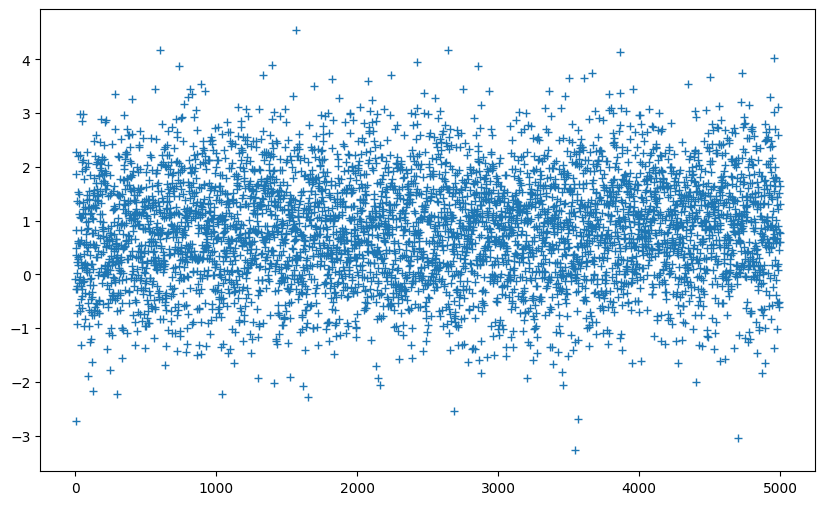

In [132]:
plt.figure(figsize=(10, 6))
plt.plot(range(n_episodes), returns ,'+')
plt.show()

In [ ]:
def upper_confidence_bound(env,
                           c=2,
                           n_episodes=1000):
    Q = np.zeros((env.action_space.n), dtype=np.float64)
    N = np.zeros((env.action_space.n), dtype=np.int)

    Qe = np.empty((n_episodes, env.action_space.n), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=np.int)
    name = 'UCB {}'.format(c)
    for e in tqdm(range(n_episodes),
                  desc='Episodes for: ' + name,
                  leave=False):
        action = e
        if e >= len(Q):
            U = c * np.sqrt(np.log(e)/N)
            action = np.argmax(Q + U)

        _, reward, _, _ = env.step(action)
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]

        Qe[e] = Q
        returns[e] = reward
        actions[e] = action
    return name, returns, Qe, actions

## Thomson Sampling